Sample of Transaction Data:
        date corridor    volume_usd    fx_rate  net_revenue_0.015  \
0 2025-01-01  USD/INR  9.959642e+05  83.099343       14939.462565   
1 2025-01-02  USD/INR  1.003932e+06  82.972347       15058.976393   
2 2025-01-03  USD/INR  9.000900e+05  83.129538       13501.349487   
3 2025-01-04  USD/INR  1.045816e+06  83.304606       15687.245756   
4 2025-01-05  USD/INR  1.017324e+06  82.953169       15259.866357   

   net_revenue_0.02  net_revenue_0.025  
0      19919.283420       24899.104275  
1      20078.635190       25098.293988  
2      18001.799315       22502.249144  
3      20916.327675       26145.409593  
4      20346.488476       25433.110595  


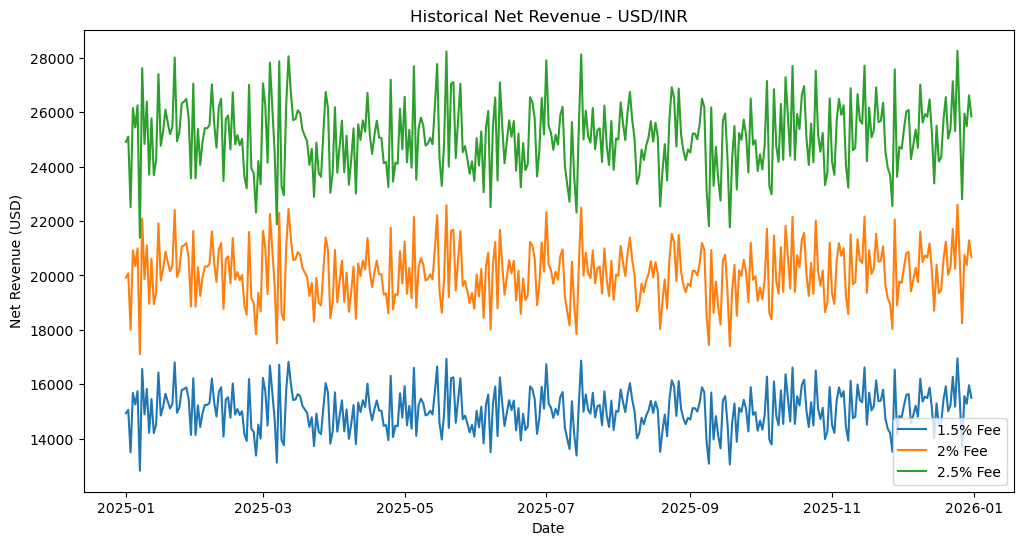

20:28:14 - cmdstanpy - INFO - Chain [1] start processing
20:28:14 - cmdstanpy - INFO - Chain [1] done processing


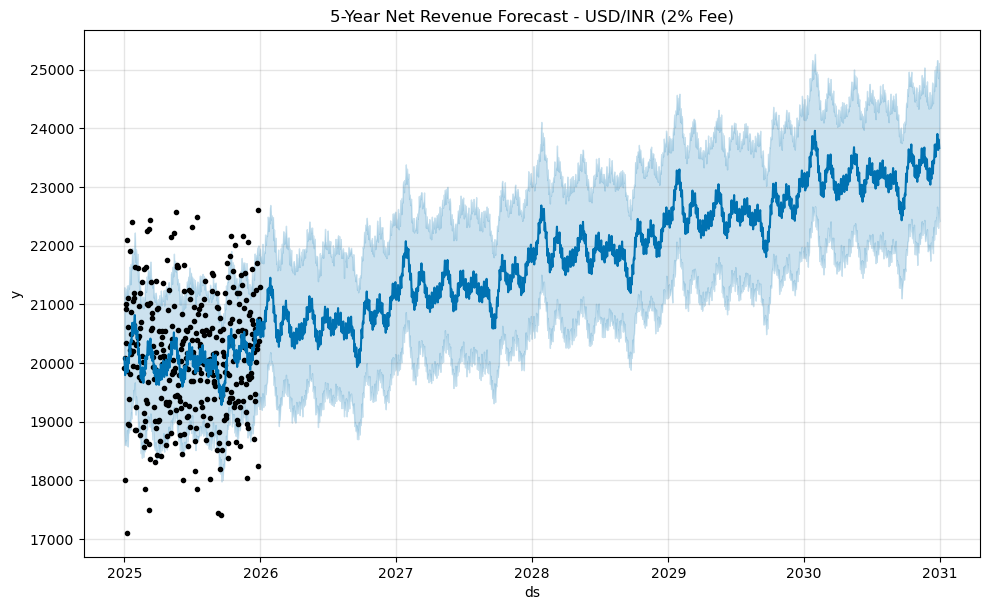


Fee Scenario Results (Total Net Revenue over 5 years):
1.5% fee: $35,571,833
2.0% fee: $47,429,111
2.5% fee: $59,286,388


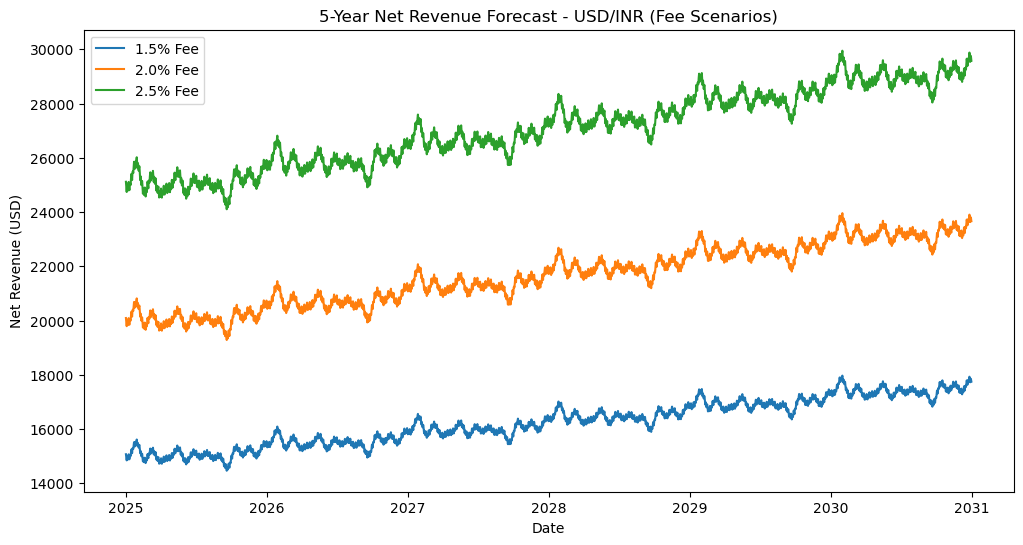


Forecast results saved to forecast_fee_scenarios.csv


In [ ]:
# Transaction Forecasting with Fee Scenarios
# Author: Shikshya Bhattachan
# GitHub: github.com/s3achan

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# -------------------------------
# 2. Load Synthetic Dataset
# -------------------------------
# Make sure synthetic_transaction_data.csv is in the same folder
txn_data = pd.read_csv("data/synthetic_transaction_data.csv", parse_dates=["date"])
print("Sample of Transaction Data:")
print(txn_data.head())

# -------------------------------
# 3. Corridor Selection
# -------------------------------
corridor = "USD/INR"   # Change to USD/MXN or USD/PHP for other corridors
df_corridor = txn_data[txn_data["corridor"] == corridor]

# -------------------------------
# 4. Exploratory Visualization
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(df_corridor["date"], df_corridor["net_revenue_0.015"], label="1.5% Fee")
plt.plot(df_corridor["date"], df_corridor["net_revenue_0.02"], label="2% Fee")
plt.plot(df_corridor["date"], df_corridor["net_revenue_0.025"], label="2.5% Fee")
plt.title(f"Historical Net Revenue - {corridor}")
plt.xlabel("Date")
plt.ylabel("Net Revenue (USD)")
plt.legend()
plt.show()

# -------------------------------
# 5. Prepare Data for Forecasting
# -------------------------------
# Use 2% fee as baseline for Prophet
df = df_corridor.rename(columns={"date":"ds","net_revenue_0.02":"y"})

# -------------------------------
# 6. Prophet Forecasting Model
# -------------------------------
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(df)

future = model.make_future_dataframe(periods=365*5)  # forecast 5 years ahead
forecast = model.predict(future)

# -------------------------------
# 7. Forecast Plot
# -------------------------------
fig = model.plot(forecast)
plt.title(f"5-Year Net Revenue Forecast - {corridor} (2% Fee)")
plt.show()

# -------------------------------
# 8. Fee Scenario Analysis
# -------------------------------
fees = [0.015, 0.02, 0.025]
results = {}

for fee in fees:
    # Scale relative to baseline (2% fee)
    forecast[f"net_revenue_{fee}"] = forecast["yhat"] * (fee/0.02)
    results[fee] = forecast[f"net_revenue_{fee}"].sum()

print("\nFee Scenario Results (Total Net Revenue over 5 years):")
for fee, total in results.items():
    print(f"{fee*100:.1f}% fee: ${total:,.0f}")

# -------------------------------
# 9. Scenario Comparison Plot
# -------------------------------
plt.figure(figsize=(12,6))
for fee in fees:
    plt.plot(forecast["ds"], forecast[f"net_revenue_{fee}"], label=f"{fee*100:.1f}% Fee")
plt.title(f"5-Year Net Revenue Forecast - {corridor} (Fee Scenarios)")
plt.xlabel("Date")
plt.ylabel("Net Revenue (USD)")
plt.legend()
plt.show()

# -------------------------------
# 10. Save Forecast Results
# -------------------------------
forecast.to_csv("forecast_fee_scenarios.csv", index=False)
print("\nForecast results saved to forecast_fee_scenarios.csv")
